In [1]:
import pandas as pd
import os
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df=pd.read_json("C:\\Users\\speed\\OneDrive\\Documents\\Documen\\20230126_data.json",lines=True)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4290783 entries, 0 to 4290782
Data columns (total 10 columns):
 #   Column        Dtype         
---  ------        -----         
 0   receive_time  datetime64[ns]
 1   device_id     object        
 2   device        object        
 3   device_name   object        
 4   platform      object        
 5   isp           object        
 6   ItemName      object        
 7   ItemId        object        
 8   AppId         object        
 9   Event         object        
dtypes: datetime64[ns](1), object(9)
memory usage: 327.4+ MB


In [4]:
df

,receive_time,device_id,device,device_name,platform,isp,ItemName,ItemId,AppId,Event
0,2023-01-26 20:02:59,D4:CF:F9:63:8C:23,BoxOTT,SEI500FPT,fplay-ottbox-sei-2020,fpt,VTV5 HD,vtv5-hd,IPTV,StartChannel
1,2023-01-26 20:02:59,D4:CF:F9:63:6B:C0,BoxOTT,SEI500FPT,fplay-ottbox-sei-2020,vnpt,VTV5 HD,vtv5-hd,IPTV,StartChannel
2,2023-01-26 20:02:59,F5AYANSVAEPIF,SmartTV,Samsung-2021,smarttv-ss-nextgen,vnpt,VTV4 HD,vtv4-hd,IPTV,StartChannel
3,2023-01-26 20:02:59,10:39:4E:8A:17:7E,BoxOTT,FHRT2X,fplay-ottbox-hisense-2022,vnpt,FPT Play,fpt-play,IPTV,StartChannel
4,2023-01-26 20:02:59,bf3b8fcf5ef5ddae,Mobile,OPPO CPH2179,Android - Normal,fpt,Ai Cũng Biết Em Yêu Anh,635c92a0b92a03f3c241fd5e,home,StartMovie
...,...,...,...,...,...,...,...,...,...,...
4290778,2023-01-26 02:59:59,D4:CF:F9:A1:56:47,BoxOTT,SEI500FPT,fplay-ottbox-sei-2020,fpt,HTVC Phụ Nữ,htvc-phu-nu,IPTV,StartChannel
4290779,2023-01-26 03:59:59,D4:CF:F9:92:EB:9D,BoxOTT,SEI500FPT,fplay-ottbox-sei-2020,viettel,Vĩnh Long 2 HD,vinh-long-2,IPTV,StartChannel
4290780,2023-01-26 03:59:59,6079cb6b6c2274d,SmartTvAndroid,aosp_philips_vi_dvb,smart-tv-normal-no-drm,vnpt,VTC1 HD,vtc1,IPTV,StartChannel
4290781,2023-01-26 03:59:59,10:39:4E:97:8A:0F,BoxOTT,FHRT2X,fplay-ottbox-hisense-2022,fpt,VTV8 HD,vtv8-hd,IPTV,StartChannel


In [5]:
df['Event']=df['Event'].replace('PrviousMovie','PreviousMovie')

In [6]:
df['Event'].unique()

array(['StartChannel', 'StartMovie', 'NextMovie', 'PreviousMovie',
       'StartTrailer', 'StartLiveShow', 'NextTrailer'], dtype=object)

In [7]:
df['date']=df['receive_time'].dt.date

In [8]:
df['hour']=df['receive_time'].dt.hour

In [9]:
general_info=df[['date','hour','device','platform','ItemName','AppId']]

<br> Overview

<b> Trending

<br> Số lượt truy cập theo giờ

In [10]:
h_device=df.groupby('hour').agg(Device_count=('device','count')).reset_index()

In [11]:
h_device

,hour,Device_count
0,0,51816
1,1,29543
2,2,22974
3,3,24161
4,4,26433
5,5,51819
6,6,82695
7,7,140816
8,8,170002
9,9,184850


<Axes: ylabel='hour'>

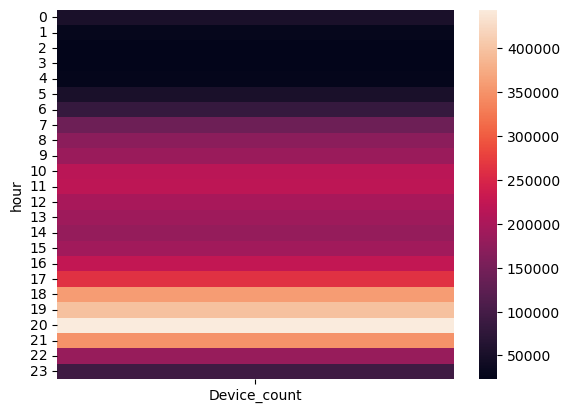

In [12]:
sns.heatmap(h_device.set_index('hour'))

<br>Tấn suất sử dụng dịch vụ theo từng filter

In [13]:
general_info.value_counts().reset_index()

,date,hour,device,platform,ItemName,AppId,count
0,2023-01-26,18,SmartTV,smarttv-ss-nextgen,VTV1 HD,IPTV,18357
1,2023-01-26,19,SmartTV,smarttv-ss-nextgen,VTV1 HD,IPTV,15613
2,2023-01-26,18,BoxOTT,fplay-ottbox-sei-2020,VTV1 HD,IPTV,14807
3,2023-01-26,19,BoxOTT,fplay-ottbox-sei-2020,VTV1 HD,IPTV,14134
4,2023-01-26,18,BoxOTT,fplay-ottbox-hisense-2022,VTV1 HD,IPTV,13144
...,...,...,...,...,...,...,...
368348,2023-01-26,0,BoxOTT,fplay-ottbox-hisense-2022,Ai Cũng Biết Em Yêu Anh,series,1
368349,2023-01-26,23,WebOS,macOS,Tội Ác Vô Hình - Blind,series,1
368350,2023-01-26,23,WebOS,macOS,Yêu Thầm Anh Xã - My Husband In Law,,1
368351,2023-01-26,0,BoxOTT,fplay-ottbox-hisense-2022,Biệt Đội Đánh Thuê 3,home,1


In [14]:
general_info['ItemName'].value_counts().reset_index()

,ItemName,count
0,VTV1 HD,531825
1,VTV3 HD,268745
2,Vĩnh Long 1 HD,184151
3,Vĩnh Long 3 HD,112323
4,VTV2 HD,108974
...,...,...
25771,Một Mất Một Còn - Tập 6,1
25772,Ngôi Sao Sáng Nhất Bầu Trời Đêm - Tập 15,1
25773,Bạn Muốn Hẹn Hò 2023 - Tập 6,1
25774,Pokémon (Phần 10) - Tập 10,1


In [15]:
general_info['device'].value_counts().reset_index()

,device,count
0,BoxOTT,1982586
1,SmartTvAndroid,1073534
2,SmartTV,837684
3,Mobile,354321
4,WebOS,42658


In [16]:
general_info['platform'].value_counts().reset_index()

,platform,count
0,fplay-ottbox-sei-2020,971678
1,fplay-ottbox-hisense-2022,860781
2,smarttv-ss-nextgen,625125
3,smarttv-sony-android,591070
4,smarttv-tcl-android,236614
5,smarttv-lg-nextgen,212555
6,smart-tv-normal,210884
7,Android - Normal,207484
8,IOS,146837
9,fplay-ottbox-sdmc-2020,122295


In [17]:
general_info['AppId'].value_counts().reset_index()

,AppId,count
0,IPTV,3224394
1,home,463705
2,series,168044
3,SEARCH,99856
4,,70512
...,...,...
117,com.refuelgames.rally,1
118,com.tranducanh.appdrawer,1
119,com.flex.kekara,1
120,busidol.atv.tower,1


In [21]:
count_df=df.groupby(['Event','ItemName']).agg({'ItemName':'count'})

In [24]:
count_df=df.groupby(['Event','ItemName']).size().reset_index()

In [26]:
count_df

,Event,ItemName,0
0,NextMovie,,3
1,NextMovie,Alexis Chavarria vs Juan Antonio Velazquez,1
2,NextMovie,Dương Thúy Vi giành huy chương vàng kiến thuậ...,1
3,NextMovie,HLV Park Hang Seo: 'Chưa trải qua giải nào nh...,1
4,NextMovie,Hài Dân Gian Ngắn (Phần 1),175
...,...,...,...
39035,StartTrailer,"Đứng Lại, Hoa Tiểu Thư",2
39036,StartTrailer,Đừng Hỏi Em Vì Sao - Mỹ Tâm,5
39037,StartTrailer,"Đừng Như Thiệu Bắc Sênh, Tỏ Tình Mà Làm Màu Qu...",2
39038,StartTrailer,Ấp úng khi xin lỗi vợ,1


<br> Đếm số lần event được thực hiện theo event

In [30]:
count_df['Event'].value_counts().reset_index()

,Event,count
0,StartMovie,21575
1,NextMovie,13832
2,PreviousMovie,2096
3,StartTrailer,1193
4,StartChannel,193
5,StartLiveShow,130
6,NextTrailer,21


In [68]:
count_df.groupby(['Event'])['ItemName'].count()

Event
NextMovie        13832
NextTrailer         21
PreviousMovie     2096
StartChannel       193
StartLiveShow      130
StartMovie       21575
StartTrailer      1193
Name: ItemName, dtype: int64

<br> Top10 movie

In [36]:
df[df['Event'].str.contains('movie', case=False, na=False)]['ItemName'].value_counts().head(10)

ItemName
Hướng Gió Mà Đi                 28612
Khanh Khanh Nhật Thường         15738
Hạ Cuối Tình Đầu                14508
Tinh Hà Xán Lạn                 12246
Vẻ Đẹp Đích Thực                 9981
Buông Tay Đi Đồ Ngốc 2           8766
Sứ Giả Thần Chết                 8411
Định Luật 80/20 Của Tình Yêu     7983
Học Viện Anh Hùng (Phần 6)       7933
Thử Thách Thần Tượng             6903
Name: count, dtype: int64

<br> Top 10 channel

In [37]:
df[df['Event'].str.contains('channel', case=False, na=False)]['ItemName'].value_counts().head(10)

ItemName
VTV1 HD           531824
VTV3 HD           268745
Vĩnh Long 1 HD    184150
Vĩnh Long 3 HD    112323
VTV2 HD           108974
Vĩnh Long 2 HD    106044
VTV5 HD            97625
VTV Cần Thơ        94002
VTV4 HD            77748
Đồng Tháp          75924
Name: count, dtype: int64